In [46]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import gaussian_kde

plt.rcParams["figure.figsize"] = (7, 4)


In [58]:
"""
The scaling controller is effectively acting like a “regularizer” on attention diffusion; 
this helps multi-evidence aggregation but hurts precise span selection.
"""

'\nThe scaling controller is effectively acting like a “regularizer” on attention diffusion; this helps multi-evidence aggregation but hurts precise span selection\n'

In [30]:
def load_entropy_logs(path):
    examples = []
    with open(path, "r") as f:
        for line in f:
            obj = json.loads(line)
            log = obj["entropy_log"]
            # since we are comparing corr(ΔT[t], ΔH[t+1]), it requires minimum 3 steps 
            # short answers dont exhibit entropy spikes or controller recovery or any meaningful temp dynamics
            if len(log) < 3:
                continue
            examples.append({
                "example_id": obj.get("example_id"),
                "entropy": np.array([x["entropy_mean"] for x in log]),
                "temp": np.array([x["temp_mean"] for x in log]),
            })
    return examples


baseline_qa1 = load_entropy_logs("qa_1_entropy_attn_entropy_logs_baseline.jsonl")
scaled_qa1   = load_entropy_logs("qa_1_entropy_attn_entropy_logs_scaled.jsonl")

baseline_qa2 = load_entropy_logs("qa_2_entropy_attn_entropy_logs_baseline.jsonl")
scaled_qa2   = load_entropy_logs("qa_2_entropy_attn_entropy_logs_scaled.jsonl")

print(len(baseline_qa1), "qa1 baseline examples")
print(len(scaled_qa1), "qa1 scaled examples")
print()
print(len(baseline_qa2), "qa2 baseline examples")
print(len(scaled_qa2), "qa2 scaled examples")


341 qa1 baseline examples
334 qa1 scaled examples

299 qa2 baseline examples
300 qa2 scaled examples


In [57]:
"""
check for Scaling controller sanity and health

ideal:
temp_sat_frac  < 0.20   (ideally < 0.15)
oscillation    < 0.25

Right now
~50% saturation → temp is hitting bounds half the time
~50% oscillation → temp changes direction every other step
High temp_sat_frac → kp / max_step too big
High oscillation → too reactive → increase EMA or reduce kp
Tiny temp_range → controller too weak

proportional gain (kp) is too high relative to the effective system sensitivity
the controller repeatedly overshoots and clamps
entropy dynamics become reaction-induced noise

fix:
1) ↓ max_step by 2× OR ↓ kp by 2×
2) higher EMA smoothing (↑ ema_beta)
"""

def controller_health_metrics(ex):
    T = ex["temp"]
    dT = T[1:] - T[:-1]

    return {
        "temp_range": T.max() - T.min(),
        "temp_sat_frac": np.mean(
            (T <= T.min() + 1e-4) | (T >= T.max() - 1e-4)
        ),
        "mean_abs_dT": np.mean(np.abs(dT)),
        "max_abs_dT": np.max(np.abs(dT)),
        "oscillation": np.sum(np.sign(dT[1:]) != np.sign(dT[:-1])),
    }


def summarize_health(examples):
    agg = defaultdict(list)
    for ex in examples:
        m = controller_health_metrics(ex)
        for k, v in m.items():
            agg[k].append(v)
    return {k: np.mean(v) for k, v in agg.items()}


print("qa_1 Scaled controller health:")
for k, v in summarize_health(scaled_qa1).items():
    print(f"{k:>15s}: {v:.4f}")

print()

print("qa_2 Scaled controller health:")
for k, v in summarize_health(scaled_qa2).items():
    print(f"{k:>15s}: {v:.4f}")

qa_1 Scaled controller health:
     temp_range: 0.0056
  temp_sat_frac: 0.4864
    mean_abs_dT: 0.0012
     max_abs_dT: 0.0017
    oscillation: 0.4880

qa_2 Scaled controller health:
     temp_range: 0.0048
  temp_sat_frac: 0.5471
    mean_abs_dT: 0.0013
     max_abs_dT: 0.0017
    oscillation: 0.4667


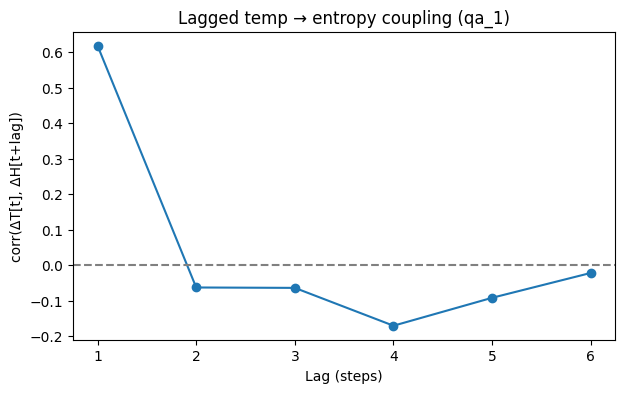

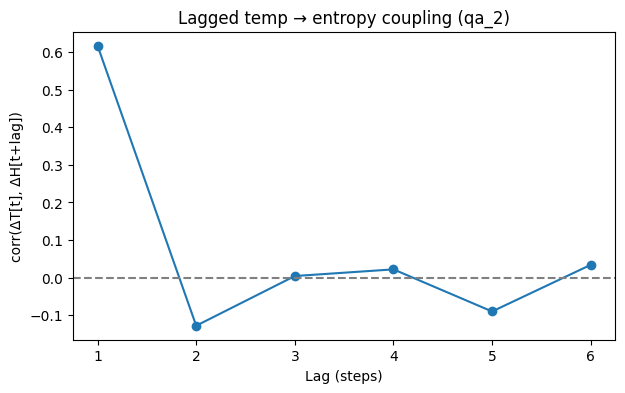

In [40]:
"""
Lag analysis: “At what delay does temperature actually affect entropy?”

strong lag-1 correlation (~0.6)

How to interpret:
Monotonic downward curve → good: more temp change reduces entropy
Flat curve → controller too weak → ↑ kp or max_step
U-shaped curve → over-sharpening at large steps → ↓ max_step *** this is the case?
Positive y → wrong direction mapping (bug)
"""

def lagged_correlation(examples, max_lag=5):
    corrs = defaultdict(list)

    for ex in examples:
        H = ex["entropy"]
        T = ex["temp"]
        dH = H[1:] - H[:-1]
        dT = T[1:] - T[:-1]

        for lag in range(1, max_lag + 1):
            if len(dT) <= lag or len(dH) <= lag:
                continue
            c = np.corrcoef(dT[:-lag], dH[lag:])[0, 1]
            if not np.isnan(c):
                corrs[lag].append(c)

    return {lag: np.mean(v) for lag, v in corrs.items()}


lag_corr_qa1 = lagged_correlation(scaled_qa1, max_lag=6)

plt.figure()
plt.plot(list(lag_corr.keys()), list(lag_corr_qa1.values()), marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Lag (steps)")
plt.ylabel("corr(ΔT[t], ΔH[t+lag])")
plt.title("Lagged temp → entropy coupling (qa_1)")
plt.show()


lag_corr_qa2 = lagged_correlation(scaled_qa2, max_lag=6)

plt.figure()
plt.plot(list(lag_corr.keys()), list(lag_corr_qa2.values()), marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Lag (steps)")
plt.ylabel("corr(ΔT[t], ΔH[t+lag])")
plt.title("Lagged temp → entropy coupling (qa_2)")
plt.show()

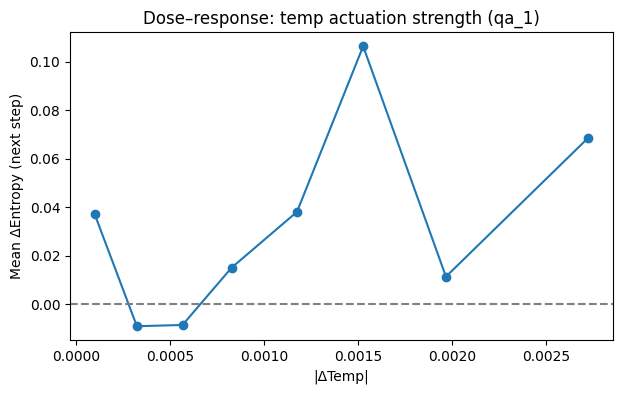

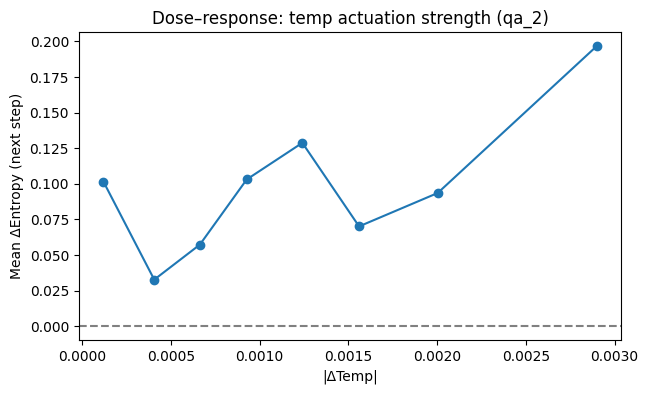

In [37]:
"""
Dose–response analysis: “How much temperature change is useful, and when does it become harmful or useless?”

This one looks bad.
|ΔT| → more entropy increase

Ideal:
Mean ΔEntropy(next) should decrease monotonically (or at least flatten)

fix:
drops then rises → cap max_step

↓ max_step by 2× (e.g. 0.0017 → 0.0008)
OR ↓ kp by 2×
OR raise temp_min slightly (e.g. 0.7 → 0.8)
"""

def dose_response(examples, nbins=8):
    dT_all = []
    dH_next_all = []

    for ex in examples:
        H = ex["entropy"]
        T = ex["temp"]
        dT = T[1:] - T[:-1]
        dH_next = H[2:] - H[1:-1]

        m = min(len(dT), len(dH_next))
        dT_all.append(dT[:m])
        dH_next_all.append(dH_next[:m])

    dT_all = np.concatenate(dT_all)
    dH_next_all = np.concatenate(dH_next_all)

    bins = np.quantile(np.abs(dT_all), np.linspace(0, 1, nbins + 1))
    bin_centers = []
    mean_dH = []

    for i in range(nbins):
        mask = (np.abs(dT_all) >= bins[i]) & (np.abs(dT_all) < bins[i + 1])
        if mask.sum() < 50:
            continue
        bin_centers.append(np.mean(np.abs(dT_all[mask])))
        mean_dH.append(np.mean(dH_next_all[mask]))

    return np.array(bin_centers), np.array(mean_dH)


x1, y1 = dose_response(scaled_qa1)

plt.figure()
plt.plot(x1, y1, marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("|ΔTemp|")
plt.ylabel("Mean ΔEntropy (next step)")
plt.title("Dose–response: temp actuation strength (qa_1)")
plt.show()

x2, y2 = dose_response(scaled_qa2)

plt.figure()
plt.plot(x2, y2, marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("|ΔTemp|")
plt.ylabel("Mean ΔEntropy (next step)")
plt.title("Dose–response: temp actuation strength (qa_2)")
plt.show()


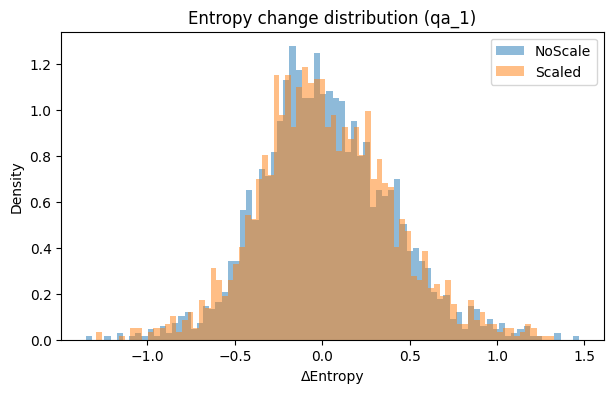

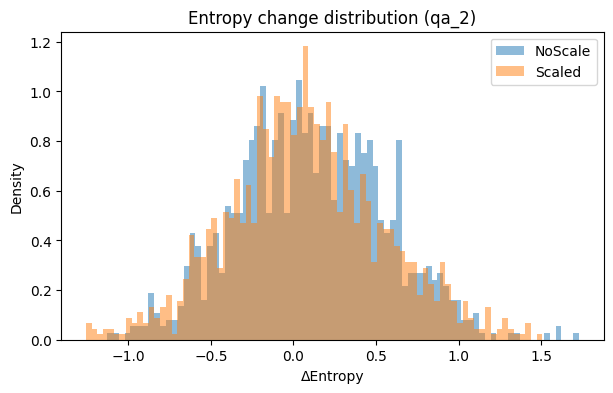

In [39]:
def delta_entropy(examples):
    return np.concatenate([
        ex["entropy"][1:] - ex["entropy"][:-1] for ex in examples
    ])


dHb_1 = delta_entropy(baseline_qa1)
dHs_1 = delta_entropy(scaled_qa1)

plt.figure()
plt.hist(dHb_1, bins=80, alpha=0.5, label="NoScale", density=True)
plt.hist(dHs_1, bins=80, alpha=0.5, label="Scaled", density=True)
plt.xlabel("ΔEntropy")
plt.ylabel("Density")
plt.title("Entropy change distribution (qa_1)")
plt.legend()
plt.show()

dHb_2 = delta_entropy(baseline_qa2)
dHs_2 = delta_entropy(scaled_qa2)

plt.figure()
plt.hist(dHb_2, bins=80, alpha=0.5, label="NoScale", density=True)
plt.hist(dHs_2, bins=80, alpha=0.5, label="Scaled", density=True)
plt.xlabel("ΔEntropy")
plt.ylabel("Density")
plt.title("Entropy change distribution (qa_2)")
plt.legend()
plt.show()


In [52]:
"""
Scaling does not meaningfully suppress entropy spikes in qa_1
But for qa_2, scaling genuinely improved entropy dynamics. 
"""

def plot_kde(dHb, dHs, task, bw_adjust=1.0,):
    kde_b = gaussian_kde(dHb)
    kde_s = gaussian_kde(dHs)

    # Bandwidth control (important!)
    kde_b.set_bandwidth(kde_b.factor * bw_adjust)
    kde_s.set_bandwidth(kde_s.factor * bw_adjust)

    xs = np.linspace(
        min(dHb.min(), dHs.min()),
        max(dHb.max(), dHs.max()),
        500
    )

    plt.figure()
    plt.plot(xs, kde_b(xs), label="NoScale")
    plt.plot(xs, kde_s(xs), label="Scaled")
    plt.axvline(0, color="gray", linestyle="--", alpha=0.5)
    plt.xlabel("ΔEntropy")
    plt.ylabel("Density")
    plt.title(f"Entropy change distribution (KDE) - {task}")
    plt.legend()
    plt.show()

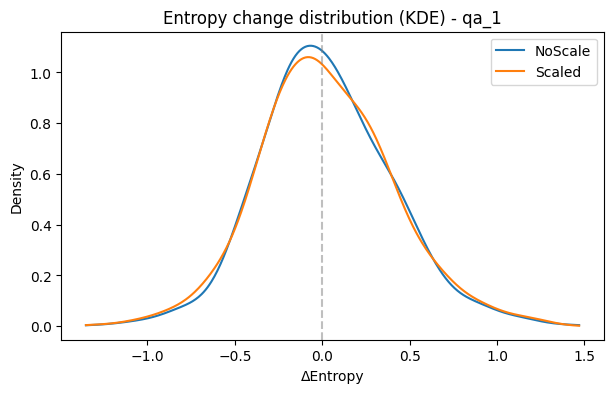

In [54]:
plot_kde(dHb_1, dHs_1, "qa_1", bw_adjust=1.2) 

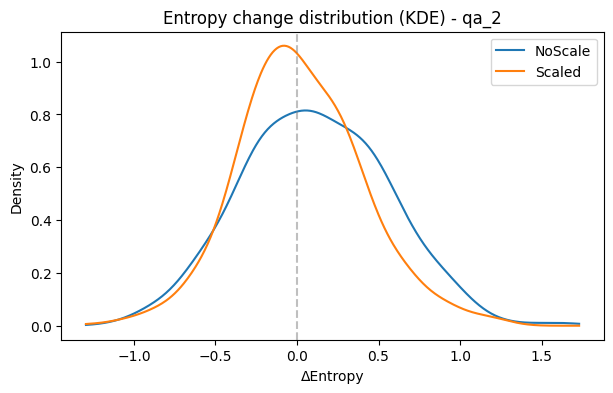

In [55]:
plot_kde(dHb_2, dHs_1, "qa_2", bw_adjust=1.2)